In [1]:
import sys
import os
# Add the project root to the Python path
project_root = '/home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique'
if project_root not in sys.path:
    sys.path.append(project_root)

import functools
import itertools
import operator
from typing import Any
import torch
from torch_geometric.data import Dataset, download_url
from torch.utils.data import random_split
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from bcos.modules import BcosLinear, BcosSequential
from sklearn.model_selection import train_test_split
from torch.nn import BCEWithLogitsLoss
from torch_geometric.datasets import BA2MotifDataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing
from torch_geometric.nn.aggr import SumAggregation
from torch_geometric.utils import add_self_loops, degree
from torchmetrics import AUROC
from torchmetrics.classification import BinaryAccuracy
from tqdm import tqdm
import networkx as nx
import matplotlib.pyplot as plt
import torch.nn.functional as F
from bcosgnn.explain import explain
from torch_sparse import matmul


## BCos Model Definitions
We define the B-Cos GNN model components (Readout, GIN Layer, and the full GNN) exactly as used in the BA-2Motifs experiments.

In [2]:
class Readout(torch.nn.Module):
    def __init__(
        self,
        in_channels,
        hidden_channels=None,
        out_channels=1,
        b=2,
        max_out=1,
        agg: str = "sum",
    ):
        super().__init__()
        if hidden_channels is None:
            self.readout = BcosLinear(in_channels, out_channels, b=b, max_out=max_out)
        else:
            hidden_channels = (
                [hidden_channels]
                if isinstance(hidden_channels, int)
                else hidden_channels
            )
            channels = [in_channels] + hidden_channels + [out_channels]
            self.readout = BcosSequential(
                *[
                    BcosLinear(d_in, d_out, b=b, max_out=max_out)
                    for d_in, d_out in zip(channels[:-1], channels[1:])
                ]
            )
        match agg:
            case "sum":
                self.agg = SumAggregation()
            case _:
                raise ValueError(f"Aggregation '{agg}' not supported.")

    def forward(self, x, batch):
        raise NotImplementedError


class AggThenReadout(Readout):
    def forward(self, x, batch):
        z = self.agg(x, batch)
        out = self.readout(z)
        return out


class ReadoutThenAgg(Readout):
    def forward(self, x, batch):
        z = self.readout(x)
        out = self.agg(z, batch)
        return out

class BcosGINConv(MessagePassing):
    def __init__(
        self,
        channels: list[int],
        b=2,
        max_out=1,
        eps: float = 0.0,
        train_eps: bool = False,
        **kwargs,
    ):
        kwargs.setdefault("aggr", "add")
        super().__init__(**kwargs)
        self.transform = BcosSequential(
            *[ 
                BcosLinear(din, dout, b=b, max_out=max_out)
                for din, dout in zip(channels[:-1], channels[1:])
            ]
        )
        self.initial_eps = eps
        if train_eps:
            self.eps = torch.nn.Parameter(torch.Tensor([eps]))
        else:
            self.register_buffer("eps", torch.Tensor([eps]))

    def forward(self, x, edge_index):
        x_original = x
        out = self.propagate(edge_index, x=x, size=None)
        out = (1 + self.eps) * x_original + out
        return self.transform(out)

    def message(self, x_j):
        return x_j

    def message_and_aggregate(self, adj_t, x):
        return matmul(adj_t, x, reduce=self.aggr)

class BCosGNN(torch.nn.Module):
    def __init__(
        self,
        node_size: int,
        hidden_channels: int | list[int],
        conv_layer: type[MessagePassing],
        num_convs: int,
        readout: Readout,
        b: float = 2,
        max_out: int = 1,
        conv_kwargs: dict[str, Any] | None = None,
    ):
        super().__init__()
        if isinstance(hidden_channels, int):
            hidden_channels = [hidden_channels]
        conv_kwargs = conv_kwargs or {}
        self.lin_node = BcosLinear(
            node_size,
            hidden_channels[0],
        )
        self.convs = torch.nn.ModuleList(
            [
                conv_layer(
                    channels=hidden_channels,
                    b=b,
                    max_out=max_out,
                    **conv_kwargs,
                )
                for _ in range(num_convs)
            ]
        )
        self.readout = readout

    def forward(self, x, edge_index, batch):
        x = self.lin_node(x)
        for conv in self.convs:
            x = conv(x, edge_index)
        return self.readout(x, batch)

## Dataset Loading and Statistics
We load the NCI1 dataset from TUDataset. NCI1 contains chemical compounds screened for activity against non-small cell lung cancer.
- **Class 0**: Inactive
- **Class 1**: Active
- **Node Features**: One-hot encoded atom types (typically).

In [3]:
from torch_geometric.datasets import TUDataset

# Load Dataset
path = os.path.join(project_root, 'data', 'TUDataset')
dataset = TUDataset(root=path, name='NCI1')

print(f'Dataset: {dataset}:')
print('====================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

# Statistics
class_counts = {0: 0, 1: 0}
total_nodes = 0
class_nodes = {0: 0, 1: 0}

for data in dataset:
    y = data.y.item()
    class_counts[y] += 1
    total_nodes += data.num_nodes
    class_nodes[y] += data.num_nodes

print(f"\nClass Distribution:")
print(f"  Class 0 (Inactive): {class_counts[0]} graphs")
print(f"  Class 1 (Active):   {class_counts[1]} graphs")

print(f"\nNode Statistics:")
print(f"  Average nodes (Total):   {total_nodes / len(dataset):.2f}")
print(f"  Average nodes (Class 0): {class_nodes[0] / class_counts[0]:.2f}")
print(f"  Average nodes (Class 1): {class_nodes[1] / class_counts[1]:.2f}")

# Split Dataset
train_dataset, test_dataset = train_test_split(dataset, test_size=0.2, random_state=42, stratify=[d.y.item() for d in dataset])
print(f"\nTrain set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Processing...
Done!
Done!


Dataset: NCI1(4110):
Number of graphs: 4110
Number of features: 37
Number of classes: 2

Class Distribution:
  Class 0 (Inactive): 2053 graphs
  Class 1 (Active):   2057 graphs

Node Statistics:
  Average nodes (Total):   29.87
  Average nodes (Class 0): 25.65
  Average nodes (Class 1): 34.07

Train set size: 3288
Test set size: 822

Class Distribution:
  Class 0 (Inactive): 2053 graphs
  Class 1 (Active):   2057 graphs

Node Statistics:
  Average nodes (Total):   29.87
  Average nodes (Class 0): 25.65
  Average nodes (Class 1): 34.07

Train set size: 3288
Test set size: 822


## Visualization of Samples
We visualize 10 random samples from each class. Since these are molecules, nodes represent atoms.
(Note: Without specific atom-type mapping, we visualize the graph structure).

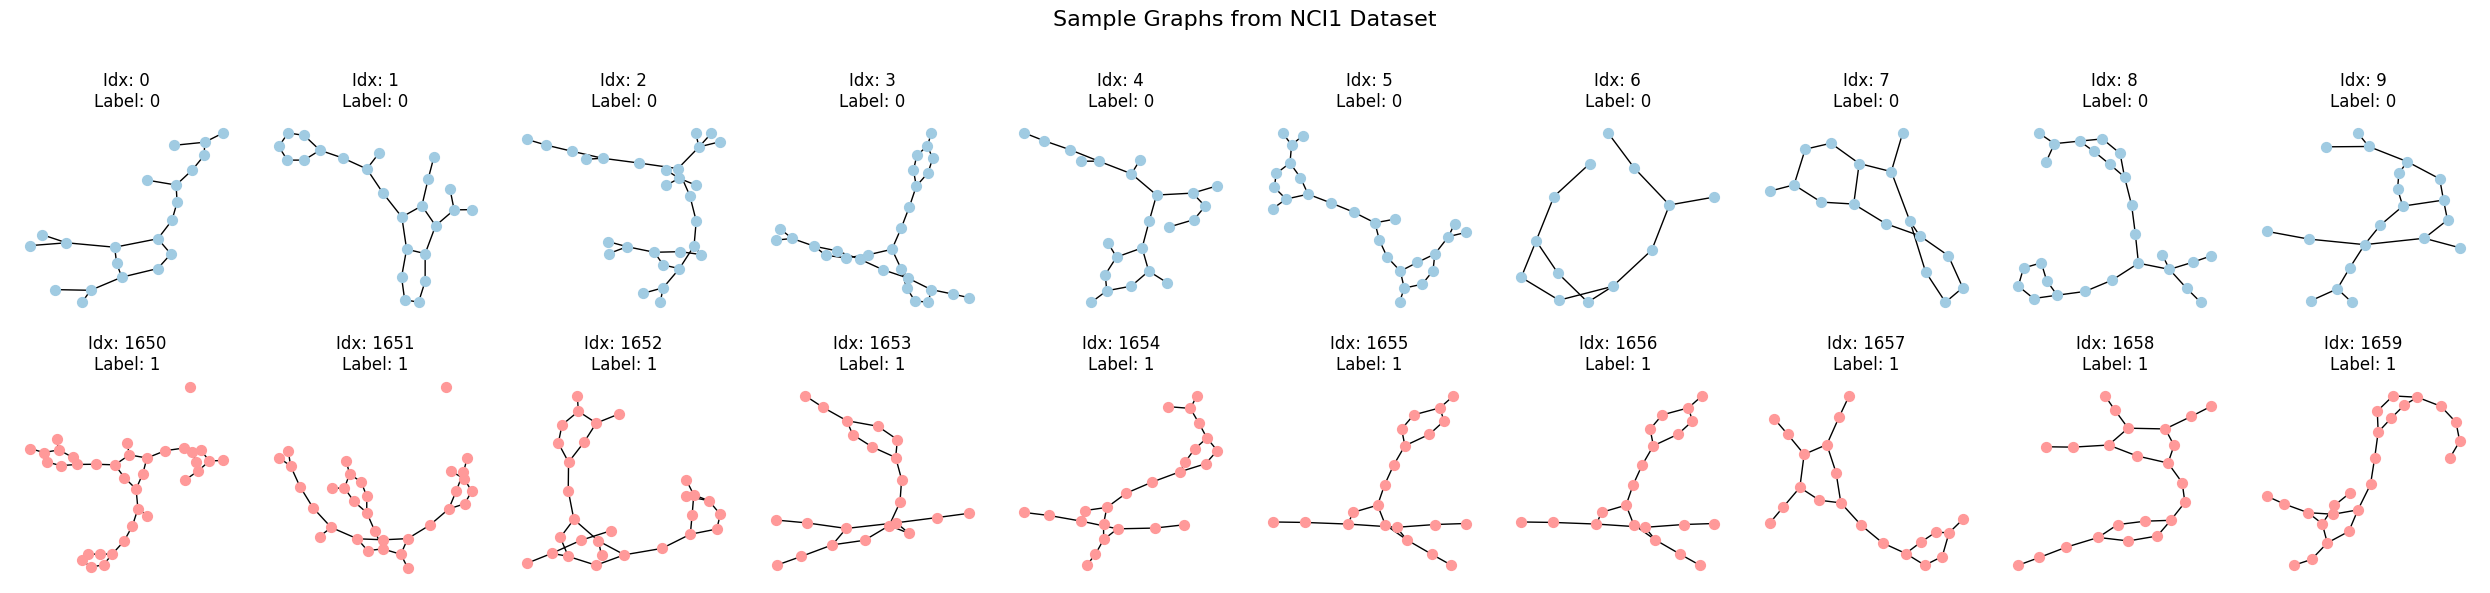

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

class_0_samples = []
class_1_samples = []

for i, data in enumerate(dataset):
    if data.y.item() == 0 and len(class_0_samples) < 10:
        class_0_samples.append((i, data))
    elif data.y.item() == 1 and len(class_1_samples) < 10:
        class_1_samples.append((i, data))
    
    if len(class_0_samples) == 10 and len(class_1_samples) == 10:
        break

fig, axes = plt.subplots(2, 10, figsize=(25, 6))
fig.suptitle("Sample Graphs from NCI1 Dataset", fontsize=16)

# Class 0 (Inactive)
for i, (original_index, data) in enumerate(class_0_samples):
    g = nx.Graph()
    g.add_nodes_from(range(data.num_nodes))
    g.add_edges_from(data.edge_index.t().tolist())
    
    ax = axes[0, i]
    pos = nx.spring_layout(g, seed=42)
    nx.draw(g, pos, ax=ax, with_labels=False, node_size=50, node_color='#A0CBE2')
    ax.set_title(f"Idx: {original_index}\nLabel: 0")

# Class 1 (Active)
for i, (original_index, data) in enumerate(class_1_samples):
    g = nx.Graph()
    g.add_nodes_from(range(data.num_nodes))
    g.add_edges_from(data.edge_index.t().tolist())
    
    ax = axes[1, i]
    pos = nx.spring_layout(g, seed=42)
    nx.draw(g, pos, ax=ax, with_labels=False, node_size=50, node_color='#ff9999')
    ax.set_title(f"Idx: {original_index}\nLabel: 1")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Training Logic
We define the training and testing loops.

In [5]:
def train_step(model, batch, criterion, optim, metrics=None):
    metrics = metrics or {}
    step_info = {"batch_size": batch.y.size(0)}
    pred = model(batch.x, batch.edge_index, batch.batch)
    step_info["pred"] = pred
    loss = criterion(pred.flatten(), batch.y.float())
    step_info["loss"] = loss.item()
    optim.zero_grad()
    loss.backward()
    optim.step()
    for name, metric in metrics.items():
        step_info[name] = metric(pred, batch.y)
    return step_info


@torch.inference_mode()
def test_step(model, batch, criterion, optim, metrics=None):
    metrics = metrics or {}
    step_info = {"batch_size": batch.y.size(0)}
    pred = model(batch.x, batch.edge_index, batch.batch)
    step_info["pred"] = pred
    loss = criterion(pred.flatten(), batch.y.float())
    step_info["loss"] = loss.item()
    for name, metric in metrics.items():
        step_info[name] = metric(pred, batch.y)
    return step_info


def run_epoch(
    step_fn,
    model,
    data_loader,
    criterion,
    optim,
    step_metrics=None,
    epoch_metrics=None,
):
    epoch_metrics = epoch_metrics or {}
    for metric in epoch_metrics.values():
        metric.reset()
    epoch_info = {"steps": []}
    for step_index, batch in enumerate(data_loader):
        step_info = step_fn(model, batch, criterion, optim, step_metrics) | {
            "step_index": step_index
        }
        epoch_info["steps"].append(step_info)
        for metric in epoch_metrics.values():
            metric.update(step_info["pred"].squeeze(), batch.y)
    for name, metric in epoch_metrics.items():
        epoch_info[name] = metric.compute()
    return epoch_info


def train_and_test_model(
    model: BCosGNN,
    train_data: list,
    test_data: list,
    transform,
    num_train_epochs: int,
    lr: float,
    batch_size: int,
):
    if transform:
        train_data = [transform(d.clone()) for d in train_data]
        test_data = [transform(d.clone()) for d in test_data]

    optim = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = BCEWithLogitsLoss()
    
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)
    
    train_epochs = [
        run_epoch(
            train_step,
            model,
            train_loader,
            criterion,
            optim,
            step_metrics=None,
            epoch_metrics={"accuracy": BinaryAccuracy()},
        )
        | {"epoch_index": epoch_index}
        for epoch_index in tqdm(
            range(num_train_epochs), f"Training {model.__class__.__name__}"
        )
    ]
    test_epoch = run_epoch(
        test_step,
        model,
        test_loader,
        criterion,
        optim,
        step_metrics=None,
        epoch_metrics={"accuracy": BinaryAccuracy()},
    )
    return train_epochs, test_epoch

## Model Training
We initialize the B-Cos GNN and train it on NCI1.
Note: NCI1 has 37 node features (one-hot atom types). We use `node_size=37`.

In [6]:
train_hyperparams = {
    "num_train_epochs": 100,
    "batch_size": 64,
    "lr": 1e-3,
}

# NCI1 usually has 37 features (one-hot atom types)
# We check the first graph to be sure
num_features = dataset.num_features
print(f"Using node_size={num_features}")

best_hyperparams = {
    "node_size": num_features,
    "hidden_channels": [64, 64],
    "conv_layer": BcosGINConv,
    "num_convs": 3,
    "readout": ReadoutThenAgg(
        in_channels=64,
        hidden_channels=[64, 64],
        b=2,
        max_out=1,
    ),
    "b": 2,
    "max_out": 1,
}

best_model = BCosGNN(**best_hyperparams)

# No transform needed if features are already present
transform = None 

train_epochs, test_epoch = train_and_test_model(
    model=best_model,
    train_data=train_dataset,
    test_data=test_dataset,
    transform=transform,
    **train_hyperparams,
)

print(f"Best model test accuracy: {test_epoch['accuracy']:.4f}")

Using node_size=37


Training BCosGNN: 100%|██████████| 100/100 [00:43<00:00,  2.30it/s]

Best model test accuracy: 0.6983


## Explanation and Visualization
We visualize the explanations for a few test graphs.
**Note**: NCI1 is a real-world dataset and does not have ground-truth node masks for explanations like the synthetic BA-2Motifs dataset. We will visualize the model's top-ranked nodes, which typically correspond to chemical functional groups relevant to the activity. We use the `bcosgnn.evaluation` module for attribution.

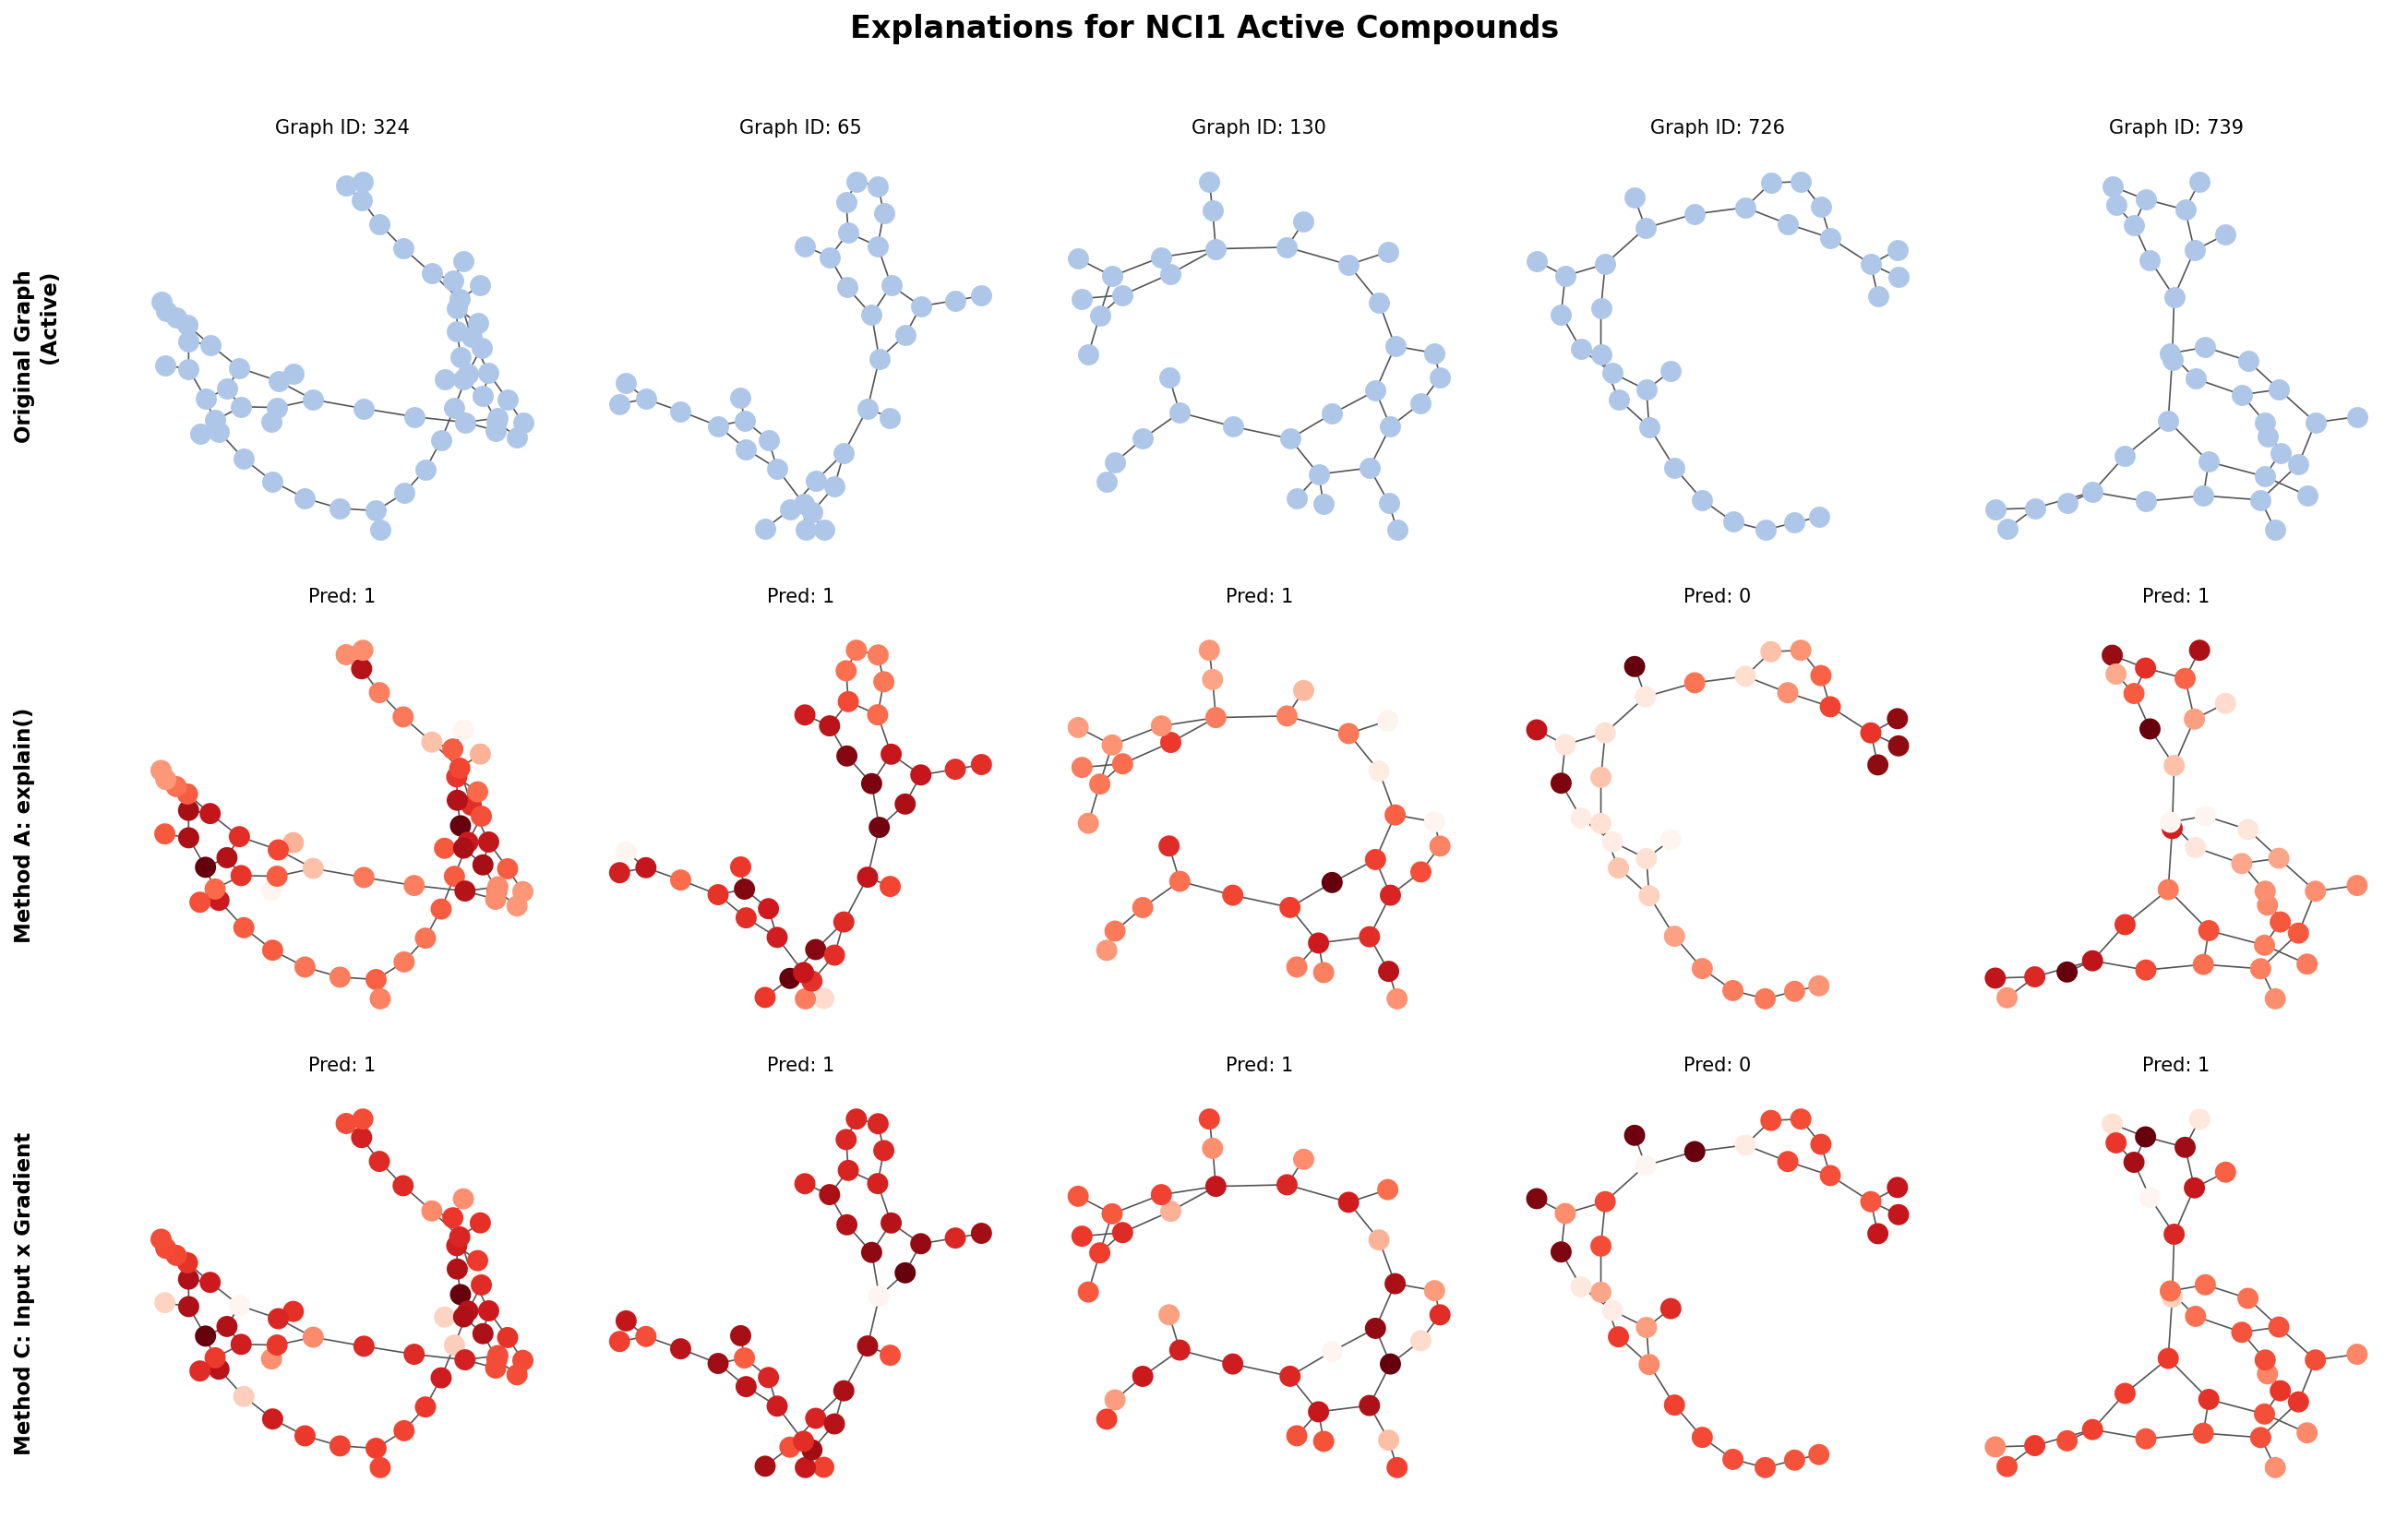

In [7]:
from bcosgnn.evaluation import get_attribution_scores

def visualize_nci1_explanations(model, dataset, num_samples=5, seed=42):
    plt.rcParams['figure.dpi'] = 150
    
    np.random.seed(seed)
    # Select samples from Class 1 (Active) as they are more interesting to explain
    active_indices = [i for i, d in enumerate(dataset) if d.y.item() == 1]
    if len(active_indices) < num_samples:
        sample_indices = active_indices
    else:
        sample_indices = np.random.choice(active_indices, num_samples, replace=False)
    
    sample_graphs = [dataset[i] for i in sample_indices]
    
    fig, axes = plt.subplots(3, num_samples, figsize=(3.5 * num_samples, 12))
    
    row_labels = [
        "Original Graph\n(Active)", 
        "Method A: explain()\n", 
        "Method C: Input x Gradient\n"
    ]
    
    for ax, label in zip(axes[:, 0], row_labels):
        ax.annotate(label, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 25, 0),
                    xycoords=ax.yaxis.label, textcoords='offset points',
                    size=11, ha='right', va='center', rotation=90, fontweight='bold')

    for col_idx, (graph_idx, data) in enumerate(zip(sample_indices, sample_graphs)):
        # Prepare data
        data_clone = data.clone()
        
        # Graph layout
        g = nx.Graph()
        g.add_nodes_from(range(data.num_nodes))
        g.add_edges_from(data.edge_index.t().tolist())
        pos = nx.spring_layout(g, seed=42) 
        
        # Row 1: Original
        ax_orig = axes[0, col_idx]
        nx.draw(g, pos, ax=ax_orig, with_labels=False, node_color='#aec7e8', 
                node_size=100, edge_color='#555555', width=0.8)
        ax_orig.set_title(f"Graph ID: {graph_idx}", fontsize=10)
        
        # Row 2: explain()
        ax_explain = axes[1, col_idx]
        try:
            scores, pred_class = get_attribution_scores(model, data_clone, method='explain')
            
            # Normalize scores for visualization (0 to 1)
            if scores.max() > scores.min():
                norm_scores = (scores - scores.min()) / (scores.max() - scores.min())
            else:
                norm_scores = scores
                
            nx.draw(g, pos, ax=ax_explain, with_labels=False, node_color=norm_scores, 
                    cmap=plt.cm.Reds, node_size=100, edge_color='#555555', width=0.8)
            ax_explain.set_title(f"Pred: {pred_class}", fontsize=10)
        except Exception as e:
            ax_explain.text(0.5, 0.5, "Failed", ha='center')
            
        # Row 3: Input x Gradient
        ax_ixg = axes[2, col_idx]
        try:
            scores, pred_class = get_attribution_scores(model, data_clone, method='input_x_gradient')
            
            if scores.max() > scores.min():
                norm_scores = (scores - scores.min()) / (scores.max() - scores.min())
            else:
                norm_scores = scores
                
            nx.draw(g, pos, ax=ax_ixg, with_labels=False, node_color=norm_scores, 
                    cmap=plt.cm.Reds, node_size=100, edge_color='#555555', width=0.8)
            ax_ixg.set_title(f"Pred: {pred_class}", fontsize=10)
        except Exception:
            ax_ixg.text(0.5, 0.5, "Failed", ha='center')

    plt.suptitle("Explanations for NCI1 Active Compounds", fontsize=16, fontweight='bold', y=0.96)
    plt.tight_layout(rect=[0, 0.05, 1, 0.94])
    plt.show()

visualize_nci1_explanations(best_model, test_dataset, num_samples=5)

In [ ]:
fbfb6